# Hessian-Guided Gradient Unlearning — Experiment Runner

Run cells top to bottom. Everything saves inside `hessian_unlearning/outputs/`.

In [36]:
# ── Cell 1: Setup — point Python at the project folder ───────────────────────
import sys, os

# Jupyter uses the folder it was launched from as cwd
NOTEBOOK_DIR = os.getcwd()
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

if not os.path.isfile(os.path.join(NOTEBOOK_DIR, 'config.py')):
    raise FileNotFoundError(
        'config.py not found.\n'
        'Open Jupyter from inside the hessian_unlearning/ folder, or run:\n'
        '  os.chdir(r"C:\\full\\path\\to\\hessian_unlearning")'
    )

print(f'Project folder: {NOTEBOOK_DIR}')
print('config.py found ✓')

Project folder: C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22
config.py found ✓


In [37]:
# ── Cell 2: Check GPU ─────────────────────────────────────────────────────────
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')

Device : cuda
GPU    : NVIDIA GeForce RTX 4090
VRAM   : 25.8 GB
PyTorch: 2.9.1+cu126


In [38]:
# ── Cell 3: Install missing packages ─────────────────────────────────────────
import subprocess
for pkg in ['tabulate', 'pandas', 'matplotlib', 'tqdm', 'scikit-learn']:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All packages ready.')

Installing scikit-learn...
All packages ready.


In [39]:
# ── Cell 4: MIGRATE old checkpoints/results from C:\content\hgu_persistent ───
# Run this once if you previously ran experiments with the old config.
# It moves everything into hessian_unlearning/outputs/ where it belongs.
# Safe to run even if already migrated — skips files that already exist.

import shutil, glob, config

OLD_BASE = r'C:\content\hgu_persistent'
NEW_BASE = config._BASE

if os.path.normpath(OLD_BASE) == os.path.normpath(NEW_BASE):
    print('Already using project folder — nothing to migrate.')
elif os.path.isdir(OLD_BASE):
    moved = 0
    for subfolder in ['checkpoints', 'results', 'plots']:
        old_sub = os.path.join(OLD_BASE, subfolder)
        new_sub = os.path.join(NEW_BASE, subfolder)
        if not os.path.isdir(old_sub):
            continue
        os.makedirs(new_sub, exist_ok=True)
        for src in glob.glob(os.path.join(old_sub, '*')):
            fname = os.path.basename(src)
            dst   = os.path.join(new_sub, fname)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
                size_mb = os.path.getsize(dst) / 1e6
                print(f'  ✓ {subfolder}/{fname}  ({size_mb:.1f} MB)')
                moved += 1
            else:
                print(f'  → already exists: {subfolder}/{fname}')
    print(f'\nMigrated {moved} file(s) to: {NEW_BASE}')
    print('You can now delete C:\\content\\hgu_persistent if you want.')
else:
    print(f'Old path not found ({OLD_BASE}) — nothing to migrate.')
    print('Will train from scratch on first run (~10 min on RTX 4090).')

  → already exists: checkpoints/cifar100_resnet18.pt
  → already exists: checkpoints/cifar10_resnet18.pt
  → already exists: checkpoints/fashion_mnist_resnet18.pt
  → already exists: results/distribution_analysis.csv
  → already exists: results/table1_cifar_comparison.csv
  → already exists: results/table2_multi_dataset.csv
  → already exists: results/table3_method_comparison.csv
  → already exists: results/table4_ablation.csv
  → already exists: results/table5_scalability.csv
  → already exists: results/table6_epsilon_sensitivity.csv
  → already exists: results/table7_sota_comparison.csv
  → already exists: plots/figure2_convergence.png
  → already exists: plots/figure3_fa_ta_tradeoff.png
  → already exists: plots/figure4_privacy_bars.png
  → already exists: plots/figure5_epsilon_sensitivity.png
  → already exists: plots/figure6_mmd_distance.png
  → already exists: plots/figure7_ablation.png

Migrated 0 file(s) to: C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\c

In [40]:
# ── Cell 5: Show output paths + cached checkpoints ───────────────────────────
print(f'Checkpoints : {config.CKPT_DIR}')
print(f'Results     : {config.RESULT_DIR}')
print(f'Plots       : {config.PLOT_DIR}')
print()
ckpts = [f for f in os.listdir(config.CKPT_DIR) if f.endswith('.pt')]
if ckpts:
    print(f'Cached checkpoints ({len(ckpts)}) — no retraining needed:')
    for c in sorted(ckpts):
        mb = os.path.getsize(os.path.join(config.CKPT_DIR, c)) / 1e6
        print(f'  ✓ {c}  ({mb:.1f} MB)')
else:
    print('No checkpoints yet.')
    print('Expected training time on RTX 4090:')
    print('  CIFAR-10  ~4 min   CIFAR-100  ~5 min   FashionMNIST ~2 min')

Checkpoints : C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints
Results     : C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results
Plots       : C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\plots

Cached checkpoints (5) — no retraining needed:
  ✓ cifar100_resnet18.pt  (45.0 MB)
  ✓ cifar100_vgg16.pt  (94.7 MB)
  ✓ cifar10_resnet18.pt  (44.8 MB)
  ✓ cifar10_vgg16.pt  (94.5 MB)
  ✓ fashion_mnist_resnet18.pt  (44.8 MB)


In [41]:
# ── Cell 6: Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

from experiments import (
    run_cifar_comparison, run_multi_dataset, run_method_comparison,
    run_ablation, run_scalability, run_epsilon_sensitivity,
    run_sota_comparison, run_distribution_analysis,
    collect_loss_curves, set_seed, get_device
)
from visualization import generate_all_figures

set_seed(42)
device = get_device()
print(f'Ready on {device}')

Ready on cuda


In [7]:
# ── Cell 7: TABLE 1 — CIFAR-10 / CIFAR-100 ───────────────────────────────────
set_seed(42)
t1 = run_cifar_comparison(device, force_retrain=False)
display(t1)


TABLE 1 — Method Comparison on CIFAR-10 / CIFAR-100

  Dataset: CIFAR10
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)

    ▶ Gradient-based Unlearning ...  

TA=83.56%  FA=45.70%  Privacy=0.57
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv

    ▶ Influence Function ...  

TA=85.15%  FA=57.20%  Privacy=0.45
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=83.84%  FA=48.40%  Privacy=0.54
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv

    ▶ SISA Training ...  

TA=81.57%  FA=22.80%  Privacy=0.80
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv

    ▶ Exact Unlearning via Retraining ...  

...

TA=61.26%  FA=31.00%  Privacy=0.35
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv

    ▶ SISA Training ...  

TA=59.70%  FA=14.00%  Privacy=0.43
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv

    ▶ Exact Unlearning via Retraining ...  

TA=59.69%  FA=14.00%  Privacy=0.43
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv

    ▶ Certified Data Removal ...  

TA=64.91%  FA=15.00%  Privacy=0.43
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table1_cifar_comparison.csv

╭───────────┬────────────────────────────────────┬──────────┬──────────┬──────────┬───────────┬────────────────┬───────────╮
│ Dataset   │ Method                             │   TA (%) │   FA (%) │   RA (%) │   MIA (%) │   Runtime (ms) │   Privacy │
├───────────┼────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼────────────────┼───────────┤
│ CIFAR10   │ Gradient-based Unlearning          │    83.56 │    45.70 │    87.77 │     47.01 │       54987.71 │      0.57 │
├───────────┼────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼─────────

,Dataset,Method,TA (%),FA (%),RA (%),MIA (%),Runtime (ms),Privacy
0,CIFAR10,Gradient-based Unlearning,83.56,45.7,87.77,47.01,54987.71,0.5672
1,CIFAR10,Influence Function,85.15,57.2,88.26,47.52,49938.00,0.4520
2,CIFAR10,Hessian-guided Gradient Unlearning,83.84,48.4,87.78,47.03,50282.31,0.5393
3,CIFAR10,SISA Training,81.57,22.8,88.10,46.67,254940.56,0.8006
4,CIFAR10,Exact Unlearning via Retraining,81.59,22.8,88.12,46.67,255976.07,0.8006
5,CIFAR10,Certified Data Removal,85.67,60.1,88.51,47.98,88338.06,0.4254
6,CIFAR100,Gradient-based Unlearning,60.98,7.0,61.53,75.24,194067.53,0.4652
7,CIFAR100,Influence Function,61.21,22.0,61.61,75.24,190639.30,0.3902
8,CIFAR100,Hessian-guided Gradient Unlearning,61.26,31.0,61.57,75.24,130813.76,0.3452
9,CIFAR100,SISA Training,59.70,14.0,60.16,75.24,1228766.61,0.4302


In [24]:
# ── Cell 8: TABLE 2 — Cross-Dataset ───────────────────────────────────────────
set_seed(42)
t2 = run_multi_dataset(device, force_retrain=False)
display(t2)


TABLE 2 — Cross-Dataset Results

  Dataset: CIFAR10
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)

    ▶ Gradient-based Unlearning ...  

TA=83.57%  FA=45.70%  Privacy=0.57
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv

    ▶ Influence Function ...  

TA=85.15%  FA=57.20%  Privacy=0.45
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=83.84%  FA=48.40%  Privacy=0.54
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv

  Dataset: CIFAR100
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar100_resnet18.pt
  ✓ Loaded cached model: cifar100_resnet18  (11.22M params)

    ▶ Gradient-based Unlearning ...  

TA=60.98%  FA=7.00%  Privacy=0.47
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv

    ▶ Influence Function ...  

...

TA=61.26%  FA=31.00%  Privacy=0.35
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv

  Dataset: FASHION_MNIST
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\fashion_mnist_resnet18.pt
  ✓ Loaded cached model: fashion_mnist_resnet18  (11.17M params)

    ▶ Gradient-based Unlearning ...  

TA=90.40%  FA=52.70%  Privacy=0.45
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv

    ▶ Influence Function ...  

TA=91.77%  FA=66.60%  Privacy=0.32
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=90.22%  FA=51.10%  Privacy=0.46
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table2_multi_dataset.csv

╭───────────────┬────────────────────────────────────┬──────────┬──────────┬──────────┬───────────┬────────────────┬───────────╮
│ Dataset       │ Method                             │   TA (%) │   FA (%) │   RA (%) │   MIA (%) │   Runtime (ms) │   Privacy │
├───────────────┼────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼────────────────┼───────────┤
│ CIFAR10       │ Gradient-based Unlearning          │    83.57 │    45.70 │    87.78 │     47.00 │       30030.59 │      0.57 │
├───────────────┼────────────────────────────────────┼──────────┼──────────┼──────────┼───────

,Dataset,Method,TA (%),FA (%),RA (%),MIA (%),Runtime (ms),Privacy
0,CIFAR10,Gradient-based Unlearning,83.57,45.7,87.78,47.00,30030.59,0.5671
1,CIFAR10,Influence Function,85.15,57.2,88.26,47.52,30235.99,0.4520
2,CIFAR10,Hessian-guided Gradient Unlearning,83.84,48.4,87.78,47.03,40806.44,0.5392
3,CIFAR100,Gradient-based Unlearning,60.98,7.0,61.53,75.24,184758.75,0.4652
4,CIFAR100,Influence Function,61.21,22.0,61.61,75.24,185669.16,0.3902
5,CIFAR100,Hessian-guided Gradient Unlearning,61.26,31.0,61.57,75.24,125995.11,0.3452
6,FASHION_MNIST,Gradient-based Unlearning,90.40,52.7,94.59,42.68,38928.91,0.4486
7,FASHION_MNIST,Influence Function,91.77,66.6,94.57,43.01,22372.33,0.3192
8,FASHION_MNIST,Hessian-guided Gradient Unlearning,90.22,51.1,94.57,42.64,30464.80,0.4633


In [25]:
# ── Cell 9: TABLE 3 — CIFAR-10 Detailed ──────────────────────────────────────
set_seed(42)
t3 = run_method_comparison(device, force_retrain=False)
display(t3)


TABLE 3 — Method Comparison (CIFAR-10 detailed)
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)

    ▶ Gradient-based Unlearning ...  

TA=83.57%  FA=45.70%  Privacy=0.57
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table3_method_comparison.csv

    ▶ Influence Function ...  

TA=85.15%  FA=57.20%  Privacy=0.45
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table3_method_comparison.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=83.84%  FA=48.40%  Privacy=0.54
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table3_method_comparison.csv

    ▶ SISA Training ...  

TA=81.59%  FA=22.80%  Privacy=0.80
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table3_method_comparison.csv

    ▶ Exact Unlearning via Retraining ...  

TA=81.58%  FA=22.80%  Privacy=0.80
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table3_method_comparison.csv

    ▶ Certified Data Removal ...  

TA=85.67%  FA=60.10%  Privacy=0.43
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table3_method_comparison.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table3_method_comparison.csv

╭───────────┬────────────────────────────────────┬──────────┬──────────┬──────────┬───────────┬────────────────┬───────────╮
│ Dataset   │ Method                             │   TA (%) │   FA (%) │   RA (%) │   MIA (%) │   Runtime (ms) │   Privacy │
├───────────┼────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼────────────────┼───────────┤
│ CIFAR10   │ Gradient-based Unlearning          │    83.57 │    45.70 │    87.78 │     47.00 │       40650.25 │      0.57 │
├───────────┼────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼───────

,Dataset,Method,TA (%),FA (%),RA (%),MIA (%),Runtime (ms),Privacy
0,CIFAR10,Gradient-based Unlearning,83.57,45.7,87.78,47.00,40650.25,0.5671
1,CIFAR10,Influence Function,85.15,57.2,88.26,47.53,40212.09,0.4520
2,CIFAR10,Hessian-guided Gradient Unlearning,83.84,48.4,87.78,47.04,38193.56,0.5394
3,CIFAR10,SISA Training,81.59,22.8,88.12,46.67,242156.07,0.8007
4,CIFAR10,Exact Unlearning via Retraining,81.58,22.8,88.11,46.67,242826.69,0.8006
5,CIFAR10,Certified Data Removal,85.67,60.1,88.51,47.97,66863.44,0.4254


In [26]:
# ── Cell 10: TABLE 4 — Ablation Study ────────────────────────────────────────
set_seed(42)
t4 = run_ablation(device, force_retrain=False)
display(t4)


TABLE 4 — Ablation Study (CIFAR-10)
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)

    ▶ Gradient-only (no Hessian, no masking) ...  

FA=7.00%  RA=79.73%  [Very Good]
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table4_ablation.csv

    ▶ Hessian-only (no masking, no inpainting) ...  

FA=57.20%  RA=88.26%  [Very Good]
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table4_ablation.csv

    ▶ Combined (no masking, no inpainting) ...  

FA=60.30%  RA=88.47%  [Very Good]
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table4_ablation.csv

    ▶ Combined + Masking only ...  

FA=0.00%  RA=88.43%  [Excellent]
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table4_ablation.csv

    ▶ Full model (Combined + Masking + Inpainting) ...  

FA=61.90%  RA=87.87%  [Very Good]
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table4_ablation.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table4_ablation.csv

╭──────────────────────────────────────────────┬──────────┬──────────┬──────────┬───────────┬───────────╮
│ Variant                                      │   FA (%) │   RA (%) │   TA (%) │   Privacy │ Rating    │
├──────────────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼───────────┤
│ Gradient-only (no Hessian, no masking)       │     7.00 │    79.73 │    72.46 │      0.93 │ Very Good │
├──────────────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼───────────┤
│ Hessian-only (no masking, no inpainting)     │    57.20 │    88.26 │    85.15 │      0.45

,Variant,FA (%),RA (%),TA (%),Privacy,Rating
0,"Gradient-only (no Hessian, no masking)",7.0,79.73,72.46,0.9333,Very Good
1,"Hessian-only (no masking, no inpainting)",57.2,88.26,85.15,0.4520,Very Good
2,"Combined (no masking, no inpainting)",60.3,88.47,85.65,0.4199,Very Good
3,Combined + Masking only,0.0,88.43,79.59,0.9333,Excellent
4,Full model (Combined + Masking + Inpainting),61.9,87.87,85.27,0.4028,Very Good


In [27]:
# ── Cell 11: TABLE 5 — Scalability ───────────────────────────────────────────
set_seed(42)
t5 = run_scalability(device, force_retrain=False)
display(t5)


TABLE 5 — Scalability Analysis
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)


  resnet18 on cifar10: 16871ms  TA=83.98%  FA=40.30%
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table5_scalability.csv
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_vgg16.pt
  ✓ Loaded cached model: cifar10_vgg16  (23.63M params)


  vgg16 on cifar10: 13883ms  TA=73.21%  FA=49.60%
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table5_scalability.csv
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar100_resnet18.pt
  ✓ Loaded cached model: cifar100_resnet18  (11.22M params)


  resnet18 on cifar100: 132566ms  TA=61.53%  FA=38.00%
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table5_scalability.csv
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar100_vgg16.pt
  ✓ Loaded cached model: cifar100_vgg16  (23.68M params)


  vgg16 on cifar100: 136175ms  TA=16.51%  FA=9.00%
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table5_scalability.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table5_scalability.csv

╭───────────┬────────────────┬──────────────────┬────────────────┬──────────┬──────────┬───────────╮
│ Dataset   │ Architecture   │   Parameters (M) │   Runtime (ms) │   TA (%) │   FA (%) │   Privacy │
├───────────┼────────────────┼──────────────────┼────────────────┼──────────┼──────────┼───────────┤
│ CIFAR10   │ resnet18       │            11.17 │       16871.00 │    83.98 │    40.30 │      0.62 │
├───────────┼────────────────┼──────────────────┼────────────────┼──────────┼──────────┼───────────┤
│ CIFAR10   │ vgg16          │            23.63 │       13882.70 │    73.21 │    49.60 │     

,Dataset,Architecture,Parameters (M),Runtime (ms),TA (%),FA (%),Privacy
0,CIFAR10,resnet18,11.17,16871.0,83.98,40.3,0.6191
1,CIFAR10,vgg16,23.63,13882.7,73.21,49.6,0.5587
2,CIFAR100,resnet18,11.22,132566.1,61.53,38.0,0.3097
3,CIFAR100,vgg16,23.68,136175.4,16.51,9.0,0.4258


In [ ]:
# ── Cell 12: TABLE 6 — ε Sensitivity (Reviewer 3 Q3) ─────────────────────────
set_seed(42)
t6 = run_epsilon_sensitivity(device, force_retrain=False)
display(t6)


TABLE 6 — ε (Masking Threshold) Sensitivity Analysis

  Dataset: CIFAR10
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)

    ▶ Hessian-guided Gradient Unlearning ...  

TA=10.01%  FA=0.00%  Privacy=0.93
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=17.53%  FA=56.10%  Privacy=0.31
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=35.42%  FA=99.50%  Privacy=0.00
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=83.00%  FA=39.80%  Privacy=0.62
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv

    ▶ Hessian-guided Gradient Unlearning ...  

...

TA=61.26%  FA=31.00%  Privacy=0.35
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=61.26%  FA=31.00%  Privacy=0.35
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=61.26%  FA=31.00%  Privacy=0.35
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=61.26%  FA=31.00%  Privacy=0.35
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table6_epsilon_sensitivity.csv

    ▶ Hessian-guided Gradient Unlearning ...  

HGU Unlearn:  12%|████████▊                                                             | 5/40 [00:12<01:53,  3.25s/it]

In [42]:
# ── Cell 13: TABLE 7 — SOTA incl. SalUn + SCRUB (Reviewer 3 Q4) ──────────────
set_seed(42)
t7 = run_sota_comparison(device, force_retrain=False)
display(t7)


TABLE 7 — SOTA Comparison (including SalUn & SCRUB)

  Dataset: CIFAR10
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)

    ▶ Gradient-based Unlearning ...  

TA=83.57%  FA=45.70%  Privacy=0.57
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv

    ▶ Hessian-guided Gradient Unlearning ...  

TA=83.84%  FA=48.40%  Privacy=0.54
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv

    ▶ SISA Training ...  

TA=81.59%  FA=22.80%  Privacy=0.80
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv

    ▶ Certified Data Removal ...  

TA=85.67%  FA=60.10%  Privacy=0.43
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv

    ▶ SalUn ...      Computing saliency mask ... masked 10.0% of params


...

TA=59.68%  FA=14.00%  Privacy=0.43
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv

    ▶ Certified Data Removal ...  

TA=64.91%  FA=15.00%  Privacy=0.43
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv

    ▶ SalUn ...      Computing saliency mask ... masked 10.0% of params


TA=61.07%  FA=36.00%  Privacy=0.32
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv

    ▶ SCRUB ...  

TA=61.40%  FA=25.00%  Privacy=0.38
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\table7_sota_comparison.csv

╭───────────┬────────────────────────────────────┬──────────┬──────────┬──────────┬───────────┬────────────────┬───────────╮
│ Dataset   │ Method                             │   TA (%) │   FA (%) │   RA (%) │   MIA (%) │   Runtime (ms) │   Privacy │
├───────────┼────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼────────────────┼───────────┤
│ CIFAR10   │ Gradient-based Unlearning          │    83.57 │    45.70 │    87.78 │     47.00 │       40210.23 │      0.57 │
├───────────┼────────────────────────────────────┼──────────┼──────────┼──────────┼───────────┼───────────

,Dataset,Method,TA (%),FA (%),RA (%),MIA (%),Runtime (ms),Privacy
0,CIFAR10,Gradient-based Unlearning,83.57,45.7,87.78,47.00,40210.23,0.5671
1,CIFAR10,Hessian-guided Gradient Unlearning,83.84,48.4,87.78,47.03,43977.58,0.5393
2,CIFAR10,SISA Training,81.59,22.8,88.12,46.67,214435.39,0.8007
3,CIFAR10,Certified Data Removal,85.67,60.1,88.51,47.97,53456.46,0.4254
4,CIFAR10,SalUn,85.87,65.3,88.16,47.61,49960.17,0.3671
5,CIFAR10,SCRUB,85.46,59.3,88.37,47.40,42243.68,0.4287
6,CIFAR100,Gradient-based Unlearning,60.98,7.0,61.53,75.24,189663.59,0.4652
7,CIFAR100,Hessian-guided Gradient Unlearning,61.26,31.0,61.57,75.24,129845.30,0.3452
8,CIFAR100,SISA Training,59.68,14.0,60.14,75.24,1222796.22,0.4302
9,CIFAR100,Certified Data Removal,64.91,15.0,65.41,75.24,268307.85,0.4252


In [43]:
# ── Cell 14: Distribution Analysis — MMD (Reviewer 1 W2) ─────────────────────
set_seed(42)
dist = run_distribution_analysis(device, force_retrain=False)
display(dist)


DISTRIBUTION ANALYSIS — MMD between pre/post features
  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)

  Extracting baseline features ... shape=(300, 512)

    ▶ Gradient-based Unlearning ...  

MMD=0.0490  FA=45.70%  TA=83.57%
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\distribution_analysis.csv

    ▶ Hessian-guided Gradient Unlearning ...  

MMD=0.0403  FA=61.90%  TA=85.81%
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\distribution_analysis.csv

    ▶ SalUn ...      Computing saliency mask ... masked 20.0% of params


MMD=0.0512  FA=65.00%  TA=85.58%
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\distribution_analysis.csv

    ▶ SCRUB ...  

MMD=0.0417  FA=64.60%  TA=86.14%
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\distribution_analysis.csv
  ✓ Saved → C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\results\distribution_analysis.csv

╭────────────────────────────────────┬──────────────────┬──────────┬──────────┬───────────╮
│ Method                             │   MMD (↑ better) │   FA (%) │   TA (%) │   Privacy │
├────────────────────────────────────┼──────────────────┼──────────┼──────────┼───────────┤
│ Gradient-based Unlearning          │           0.0490 │  45.7000 │  83.5700 │    0.5676 │
├────────────────────────────────────┼──────────────────┼──────────┼──────────┼───────────┤
│ Hessian-guided Gradient Unlearning │           0.0403 │  61.9000 │  85.8100 │    0.4037 │
├────────────────────────────────────┼──────────────────┼─

,Method,MMD (↑ better),FA (%),TA (%),Privacy
0,Gradient-based Unlearning,0.0490,45.7,83.57,0.5676
1,Hessian-guided Gradient Unlearning,0.0403,61.9,85.81,0.4037
2,SalUn,0.0512,65.0,85.58,0.3705
3,SCRUB,0.0417,64.6,86.14,0.3748


In [44]:
# ── Cell 15: Loss curves ──────────────────────────────────────────────────────
set_seed(42)
curves = collect_loss_curves(device, force_retrain=False)
print('Curves:', list(curves.keys()))


  ✓ Checkpoint loaded ← C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\checkpoints\cifar10_resnet18.pt
  ✓ Loaded cached model: cifar10_resnet18  (11.17M params)


    Computing saliency mask ... masked 20.0% of params


Curves: ['Gradient', 'Hessian-guided', 'SalUn']


In [45]:
# ── Cell 16: Generate all 8 figures ──────────────────────────────────────────
results = {
    'table1': t1, 'table2': t2, 'table3': t3, 'table4': t4,
    'table5': t5, 'table6': t6, 'table7': t7,
    'distrib': dist, 'curves': curves,
}
saved = generate_all_figures(results)
print(f'{len(saved)} figures → {config.PLOT_DIR}')

  ✓ C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\plots\figure2_convergence.png
  ✓ C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\plots\figure3_fa_ta_tradeoff.png
  ✓ C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\plots\figure4_privacy_bars.png
  ✓ C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\plots\figure5_epsilon_sensitivity.png
  ✓ C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\plots\figure6_mmd_distance.png
  ✓ C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs\plots\figure7_ablatio

figure2_convergence.png


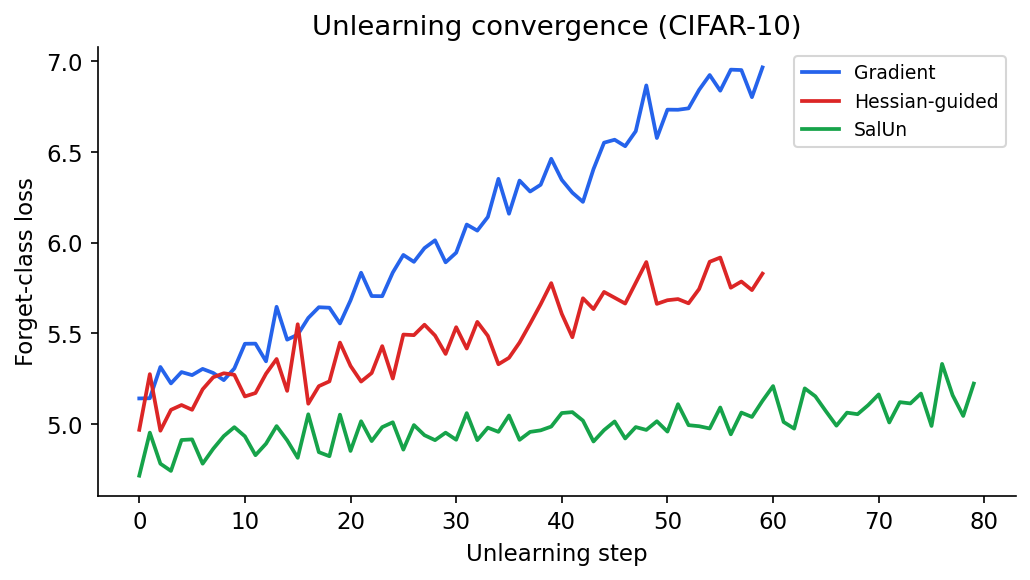

figure3_fa_ta_tradeoff.png


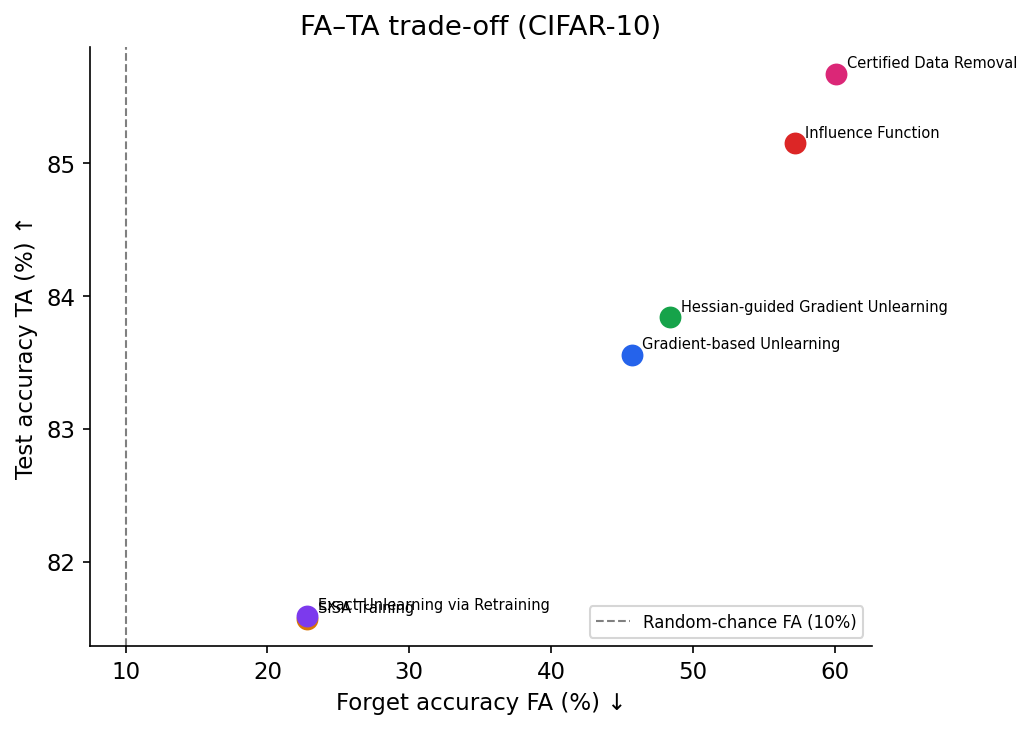

figure4_privacy_bars.png


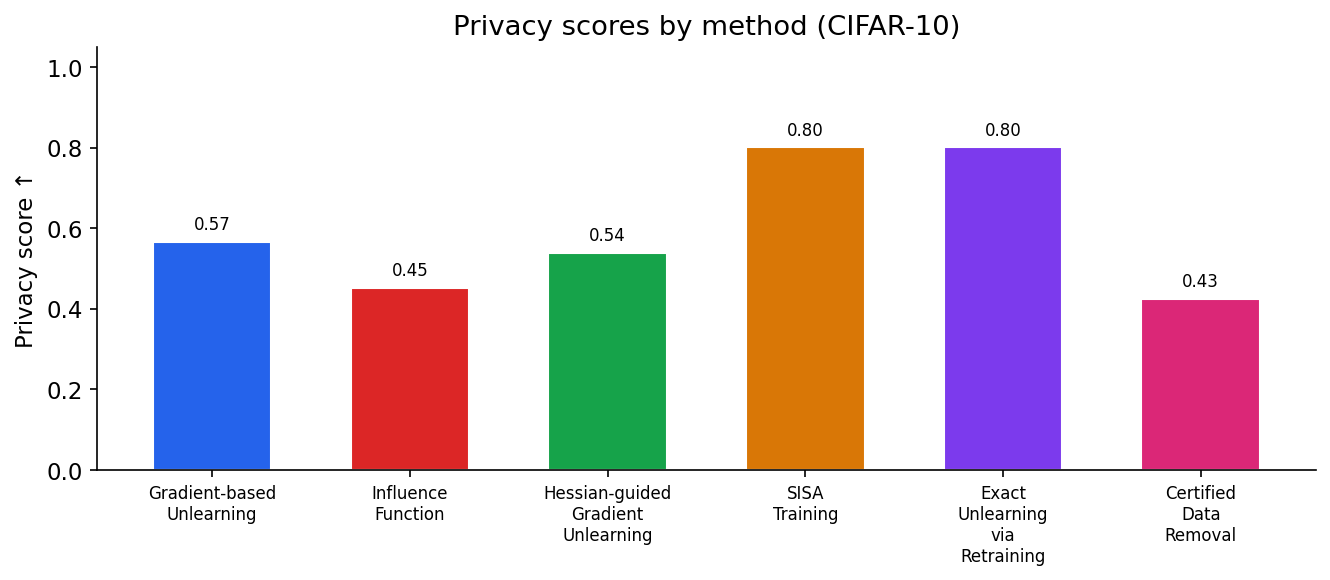

figure5_epsilon_sensitivity.png


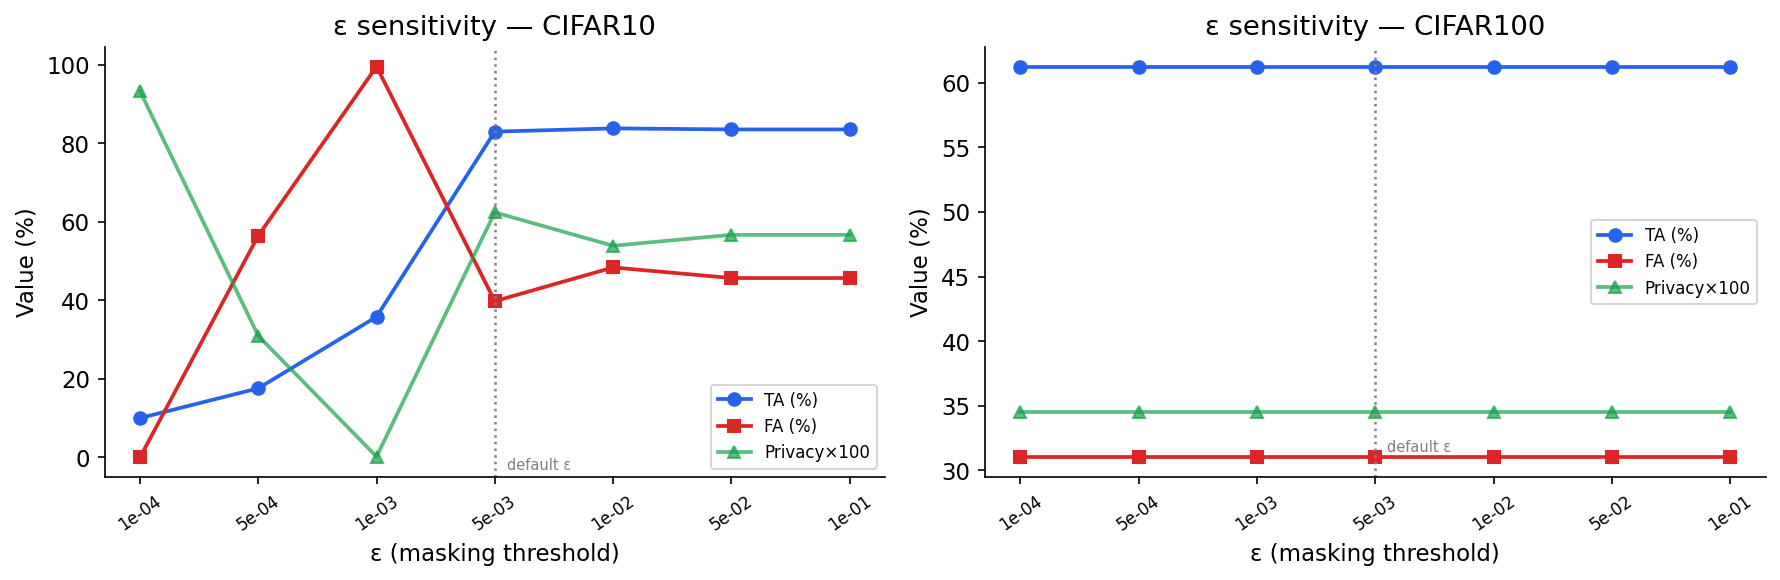

figure6_mmd_distance.png


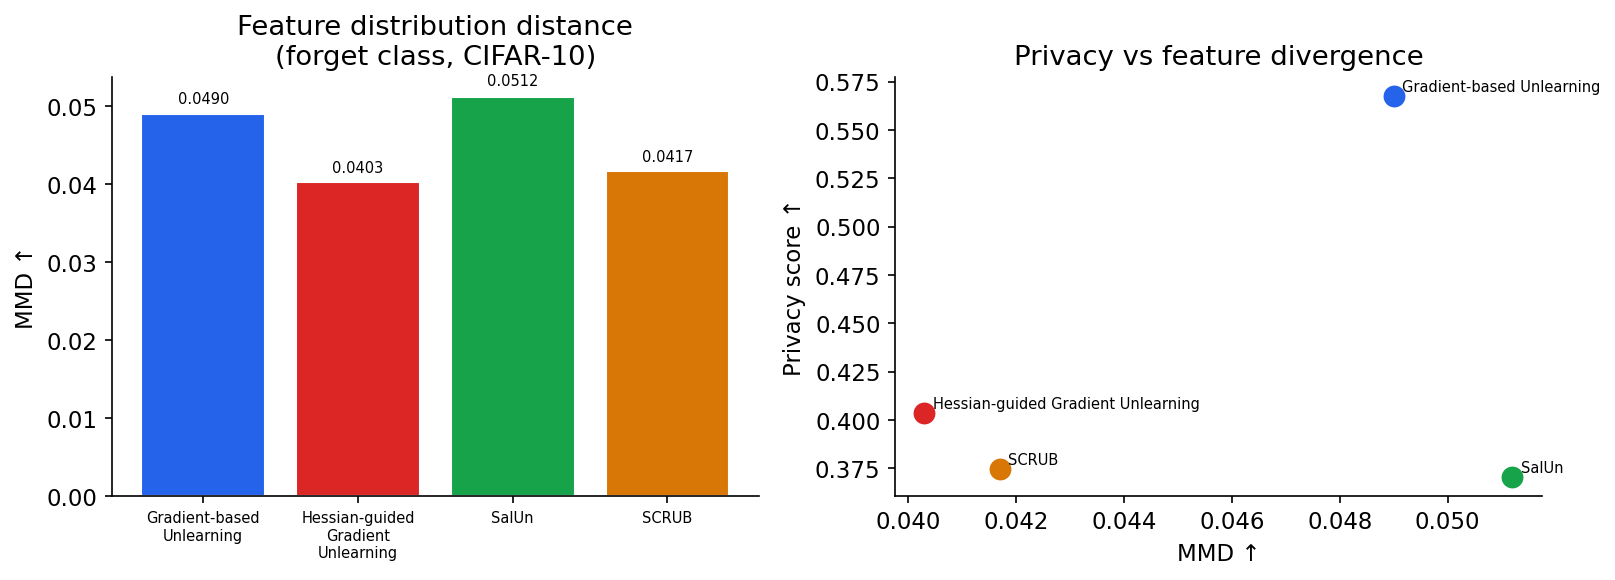

figure7_ablation.png


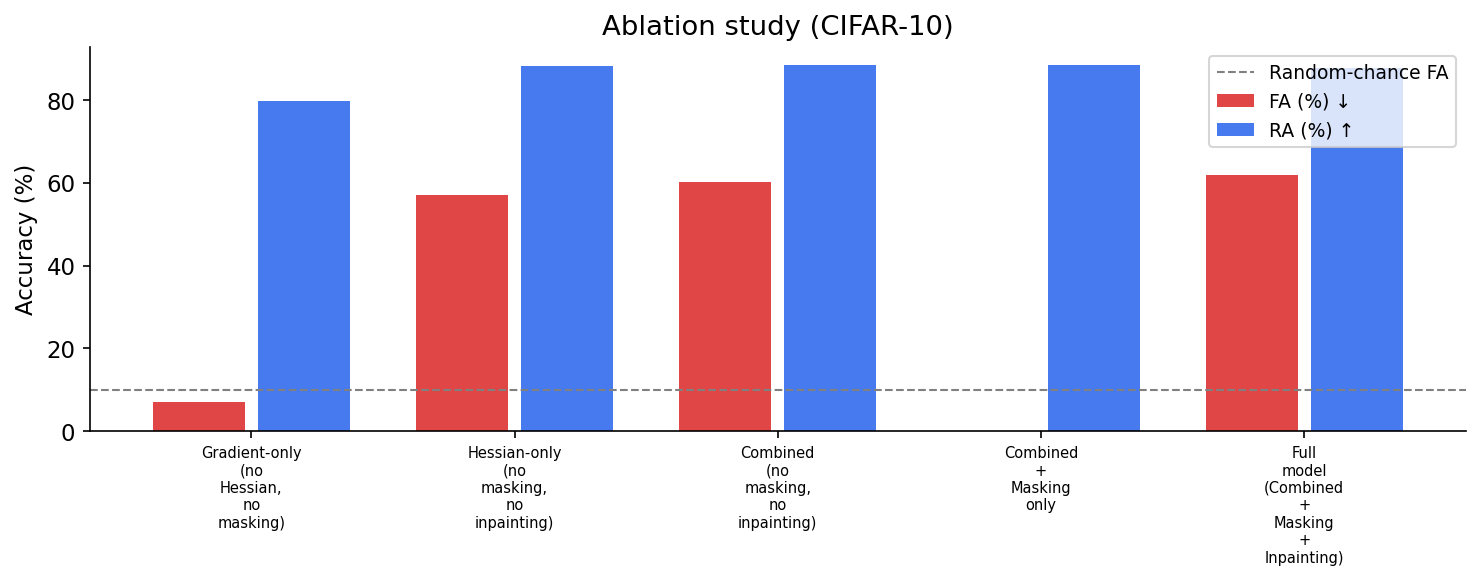

figure8_sota_comparison.png


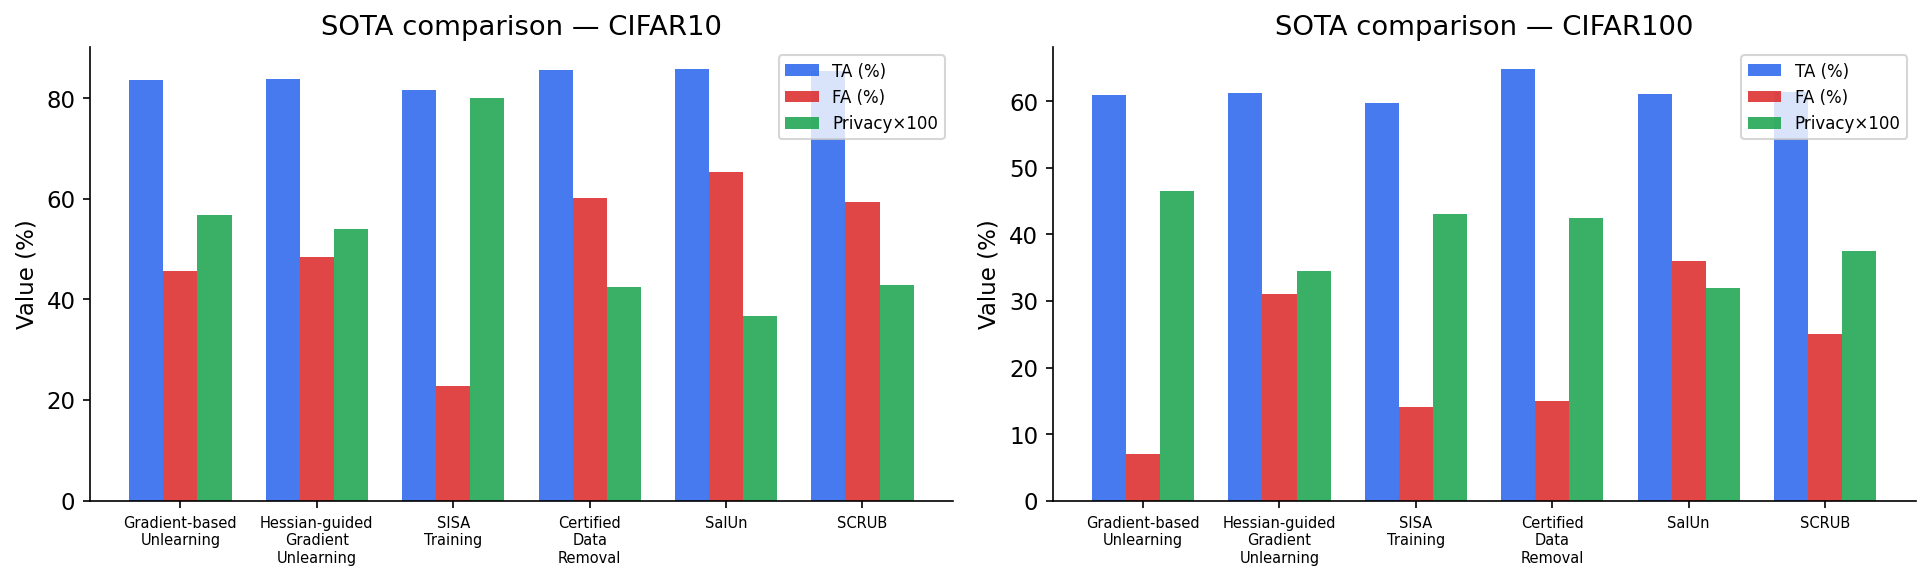

In [46]:
# ── Cell 17: View figures inline ─────────────────────────────────────────────
import glob
for fig in sorted(glob.glob(os.path.join(config.PLOT_DIR, '*.png'))):
    print(os.path.basename(fig))
    display(Image(fig, width=700))

In [47]:
# ── Cell 18: Final summary ────────────────────────────────────────────────────
import glob
print('=' * 60)
print(f'All outputs inside: {config._BASE}')
print('=' * 60)
for label, folder, ext in [
    ('Checkpoints', config.CKPT_DIR,   '*.pt'),
    ('Results',     config.RESULT_DIR, '*.csv'),
    ('Figures',     config.PLOT_DIR,   '*.png'),
]:
    files = sorted(glob.glob(os.path.join(folder, ext)))
    print(f'\n{label} ({len(files)}):')
    for f in files:
        mb = os.path.getsize(f) / 1e6
        print(f'  {os.path.basename(f):50s} {mb:.1f} MB')

All outputs inside: C:\Users\34998855\AppData\Roaming\JetBrains\PyCharm2025.1\extensions\com.intellij.database\mu_align11\hessian_unlearningv22\outputs

Checkpoints (5):
  cifar100_resnet18.pt                               45.0 MB
  cifar100_vgg16.pt                                  94.7 MB
  cifar10_resnet18.pt                                44.8 MB
  cifar10_vgg16.pt                                   94.5 MB
  fashion_mnist_resnet18.pt                          44.8 MB

Results (8):
  distribution_analysis.csv                          0.0 MB
  table1_cifar_comparison.csv                        0.0 MB
  table2_multi_dataset.csv                           0.0 MB
  table3_method_comparison.csv                       0.0 MB
  table4_ablation.csv                                0.0 MB
  table5_scalability.csv                             0.0 MB
  table6_epsilon_sensitivity.csv                     0.0 MB
  table7_sota_comparison.csv                         0.0 MB

Figures (7):
  figure2_converg

---
## Quick re-run individual experiments

In [ ]:
# Uncomment whichever you need:

# set_seed(42); t1 = run_cifar_comparison(device);      display(t1)
# set_seed(42); t4 = run_ablation(device);              display(t4)
# set_seed(42); t6 = run_epsilon_sensitivity(device);   display(t6)
# set_seed(42); t7 = run_sota_comparison(device);       display(t7)
# set_seed(42); dist = run_distribution_analysis(device); display(dist)

In [ ]:
# Force retrain one model:
# from trainer import load_or_train
# from datasets import get_loaders
# tl, vl, _, _ = get_loaders('cifar10', forget_class=0, batch_size=256)
# load_or_train('cifar10', 'resnet18', 10, 3, tl, vl, device, force_retrain=True)

In [ ]:
# If Jupyter opened in the wrong folder:
# os.chdir(r'C:\full\path\to\hessian_unlearning')
# sys.path.insert(0, os.getcwd())